# Day 6 Advanced Analytics and Risk Metrics

In [1]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print("Unique Funds:", nav["amfi_code"].nunique())
print("Rows:", len(nav))

nav.head()

Unique Funds: 40
Rows: 46000


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


### Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
funds = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

### Historical VaR and CVaR

In [4]:
#Convert Date
nav['date'] = pd.to_datetime(nav['date'])

In [5]:
#Merge fund names
nav = nav.merge(
    funds[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

In [6]:
#Sort Data
nav = nav.sort_values(
    ['amfi_code','date']
)

In [7]:
#Calculate Daily Returns
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [10]:
returns = nav[
    nav['amfi_code'] == 100016
]['daily_return'].dropna()

var = returns.quantile(0.05)

cvar = returns[
    returns <= var
].mean()

In [11]:
fund_code = nav['amfi_code'].iloc[0]

returns = nav[
    nav['amfi_code'] == fund_code
]['daily_return'].dropna()

print(returns.head())

1   -0.010306
2    0.012865
3   -0.011377
4   -0.001210
5   -0.008639
Name: daily_return, dtype: float64


In [12]:
var = returns.quantile(0.05)

cvar = returns[
    returns <= var
].mean()

print("VaR:", var)
print("CVaR:", cvar)

VaR: -0.014363639988111142
CVaR: -0.01806020763217176


In [16]:
##loop through every fund
results = []

for fund in nav['amfi_code'].unique():

    returns = nav[
        nav['amfi_code'] == fund
    ]['daily_return'].dropna()

    var = returns.quantile(0.05)

    cvar = returns[
        returns <= var
    ].mean()

    scheme_name = nav[
        nav['amfi_code'] == fund
    ]['scheme_name'].iloc[0]

    results.append([
        fund,
        scheme_name,
        var,
        cvar
    ])

In [17]:
#Convert to Dataframe
var_cvar = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'scheme_name',
        'VaR_95',
        'CVaR'
    ]
)

var_cvar.head()

,amfi_code,scheme_name,VaR_95,CVaR
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [18]:
#Finding riskiest fund
var_cvar.sort_values(
    'VaR_95'
).head()

,amfi_code,scheme_name,VaR_95,CVaR
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595


In [19]:
#Saving deliverable
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

### Rolling Sharpe

In [20]:
#Considering 5 funds
top5 = (
 performance
 .sort_values(
    'aum_crore',
    ascending=False
 )
 .head(5)
)

In [ ]:
#Chart Fig
plt.figure(figsize=(15,8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

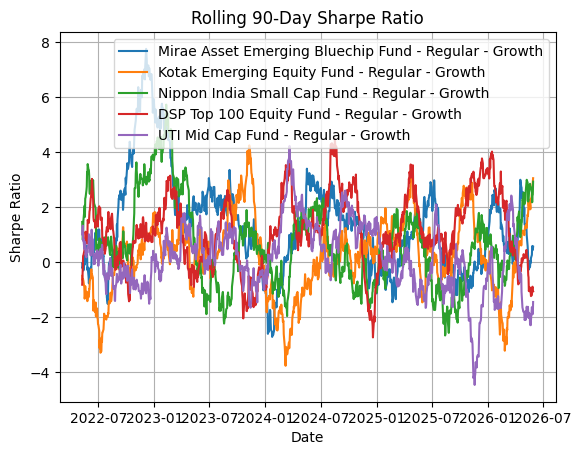

In [ ]:
#Looping in 5 funds
for fund in top5['amfi_code']:
    
    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp['rolling_mean'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
    )

    temp['rolling_std'] = (
        temp['daily_return']
        .rolling(90)
        .std()
    )

    temp['rolling_sharpe'] = (
        temp['rolling_mean']
        /
        temp['rolling_std']
    ) * np.sqrt(252)

    scheme_name = temp[
        'scheme_name'
    ].iloc[0]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=scheme_name
    )

    plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

C:\Users\Vani Arya\AppData\Local\Temp\ipykernel_21548\1049348874.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


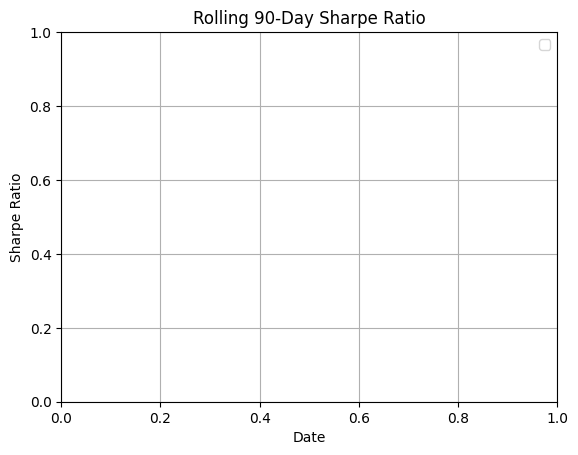

In [29]:
#Saving deliverables
plt.savefig(
    "../charts/rolling_sharpe_chart.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

### Cohort Analysis

In [30]:
#Converting Dates
transactions[
 'transaction_date'
] = pd.to_datetime(
 transactions[
 'transaction_date'
 ])

In [31]:
#first transaction for each investor
cohort = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .dt.year
)

In [32]:
#Dataframe
cohort = cohort.reset_index()

cohort.columns = [
    'investor_id',
    'cohort_year'
]

In [33]:
cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [34]:
#Merging back into transactions
transactions = transactions.merge(
    cohort,
    on='investor_id',
    how='left'
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [37]:
#Avg SIP calc
sip_txn = transactions[
    transactions['transaction_type'] == 'SIP'
]
sip_txn.head()



,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [36]:
avg_sip = (
    sip_txn
    .groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index()
)
avg_sip

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [39]:
#Total invested
total_invested = (
    transactions
    .groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index()
)
total_invested

,cohort_year,amount_inr
0,2024,3491125187
1,2025,30455243


In [40]:
##Top fund preference
transactions = transactions.merge(
    funds[
        ['amfi_code','scheme_name']
    ],
    on='amfi_code',
    how='left'
)

fund_pref = (
    transactions
    .groupby(
        ['cohort_year','scheme_name']
    )
    .size()
    .reset_index(name='count')
)

fund_pref.head()

,cohort_year,scheme_name,count
0,2024,ABSL Frontline Equity Fund - Regular - Growth,803
1,2024,ABSL Liquid Fund - Regular - Growth,832
2,2024,ABSL Small Cap Fund - Regular - Growth,844
3,2024,Axis Bluechip Fund - Direct - Growth,787
4,2024,Axis Bluechip Fund - Regular - Growth,824


In [41]:
#most popular fund in each cohort
idx = (
    fund_pref
    .groupby('cohort_year')['count']
    .idxmax()
)
top_fund = fund_pref.loc[idx]
top_fund

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [42]:
#Final cohort report
avg_sip = avg_sip.rename(
    columns={
        'amount_inr':'avg_sip_amount'
    }
)

#merge everything
total_invested = total_invested.rename(
    columns={
        'amount_inr':'total_invested'
    }
)

cohort_analysis = (
    avg_sip
    .merge(
        total_invested,
        on='cohort_year'
    )
    .merge(
        top_fund[
            ['cohort_year','scheme_name']
        ],
        on='cohort_year'
    )
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [43]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

### SIP Continuity Analysis

In [44]:
#checking transaction types
transactions['transaction_type'].value_counts()

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [45]:
#keeping only sip
sip_df = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()
sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth


In [46]:
#no. of SIP Transactions Per Investor
sip_counts = (
    sip_df
    .groupby('investor_id')
    .size()
)
sip_counts.head()

investor_id
INV000001    2
INV000002    3
INV000003    2
INV000004    6
INV000005    3
dtype: int64

In [47]:
#Keeping investors 6+ SIP transactions
valid_investors = sip_counts[
    sip_counts >= 6
].index

print(
    len(valid_investors)
)

1362


In [48]:
#filter dataset
sip_df = sip_df[
    sip_df['investor_id']
    .isin(valid_investors)
]

In [51]:
#sorting transactions
sip_df = sip_df.sort_values(
    ['investor_id',
     'transaction_date']
)

#calc gap between transactions
sip_df['gap_days'] = (
    sip_df
    .groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

#veryfying gaps
sip_df[
    ['investor_id',
     'transaction_date',
     'gap_days']
].head(20)


,investor_id,transaction_date,gap_days
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0
12003,INV000004,2024-07-07,59.0
28749,INV000004,2025-03-29,265.0
31897,INV000004,2025-05-17,49.0
9329,INV000008,2024-05-27,NaN
11113,INV000008,2024-06-23,27.0
21549,INV000008,2024-12-05,165.0
24389,INV000008,2025-01-18,44.0


In [52]:
#avg gap per investor
sip_summary = (
    sip_df
    .groupby('investor_id')
    ['gap_days']
    .mean()
    .reset_index()
)
sip_summary.head()

,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [53]:
#flag at risk investors(gap>35 days)
sip_summary['status'] = np.where(
    sip_summary['gap_days'] > 35,
    'At-Risk',
    'Healthy'
)
sip_summary.head()


,investor_id,gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [54]:
#health v/s at risk
sip_summary['status'].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [55]:
#At-Risk Percentage
at_risk_pct = (
    (sip_summary['status']
     == 'At-Risk')
    .mean()
) * 100

print(
    f"At-Risk Investors: {at_risk_pct:.2f}%"
)

At-Risk Investors: 97.80%


In [56]:
#saving deliverables
sip_summary.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

### Simple Fund Recommender

In [57]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

In [59]:
risk = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)


filtered = df[
    df['risk_grade'].str.lower()
    ==
    risk.lower()
]

#sorting by sharpe
recommendations = (
    filtered
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

#printing recommendations
print(
    recommendations[
        [
            'scheme_name',
            'risk_grade',
            'sharpe_ratio'
        ]
    ]
)

                                      scheme_name risk_grade  sharpe_ratio
21  Kotak Emerging Equity Fund - Regular - Growth       High          0.96
12       ICICI Pru Midcap Fund - Regular - Growth       High          0.95
38             DSP Midcap Fund - Regular - Growth       High          0.90


### Sector HHI Analysis

In [60]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [63]:
#% to dec
holdings['weight'] = (
    holdings['weight_pct']
    /100
)

#calc hhi
hhi = (
    holdings
    .groupby('amfi_code')['weight']
    .apply(
        lambda x:
        (x**2).sum()
    )
    .reset_index()
)

#renaming col
hhi.columns = [
    'amfi_code',
    'HHI'
]

#add fund names
hhi = hhi.merge(
    funds[
        ['amfi_code',
         'scheme_name']
    ],
    on='amfi_code',
    how='left'
)


#sorting highest hhi for most concentrated funds
hhi.sort_values(
    'HHI',
    ascending=False
).head()



,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth


In [64]:
#saving
hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

# Advanced Analytics Summary

## Key Insights

### 1. Highest Downside Risk
SBI Small Cap Fund - Direct Plan - Growth recorded the highest downside risk among all analyzed schemes with a VaR (95%) of -2.69% and a CVaR of -3.24%. This indicates that during adverse market conditions, the fund experiences larger losses compared to its peers.

### 2. Strongest Risk-Adjusted Performance
Among the high-risk category funds, Kotak Emerging Equity Fund - Regular - Growth achieved the highest Sharpe Ratio (0.96), followed closely by ICICI Pru Midcap Fund (0.95). These funds delivered the best risk-adjusted returns in their peer group.

### 3. Investor Cohort Contribution
The 2024 investor cohort contributed the highest total investment amount of approximately ₹349 million and showed a strong preference for Mirae Asset Emerging Bluechip Fund - Regular - Growth. This cohort represents the most valuable investor segment in the dataset.

### 4. SIP Continuity Risk
A significant 97.8% of investors with at least six SIP transactions were classified as At-Risk due to average transaction gaps exceeding 35 days. This suggests weak SIP continuity and highlights the need for investor engagement and retention initiatives.

### 5. Sector Concentration Analysis
Axis Bluechip Fund - Regular - Growth recorded the highest HHI score (0.206), indicating the highest sector concentration among the analyzed funds. In contrast, funds with lower HHI scores demonstrate better sector diversification and lower concentration risk.